# 05 — Génération de courbes synthétiques (VAE conditionnel)
Un VAE conditionné sur le label RS/RP génère de nouvelles courbes journalières. Les métriques comparent les synthétiques à un échantillon réel représentatif, pas aux premières lignes du dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import ks_2samp
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device : {DEVICE}")

Device : cpu


## 5.1 Préparation des données — courbes journalières

In [2]:
df_pivot = pd.read_parquet('../data/pivot.parquet')
features = pd.read_parquet('../data/features.parquet')

N_SLOTS = 48

# Construit un dataset de courbes journalières avec labels
daily_curves, daily_labels = [], []

for client_id in df_pivot.index:
    label = features.loc[client_id, 'label']   # 'RS' ou 'RP'
    serie = df_pivot.loc[client_id].values
    n_days = len(serie) // N_SLOTS
    days = serie[:n_days * N_SLOTS].reshape(n_days, N_SLOTS)
    daily_curves.append(days)
    daily_labels.extend([label] * n_days)

X_raw    = np.vstack(daily_curves)   # (N_total, 48)
y_labels = np.array(daily_labels)

print(f"Courbes totales : {X_raw.shape}")
print(f"RS : {(y_labels == 'RS').sum()}  |  RP : {(y_labels == 'RP').sum()}")

Courbes totales : (182000, 48)
RS : 78260  |  RP : 103740


## 5.2 Normalisation & encodage du label

In [3]:
# Filtre les journées quasiment nulles (jours sans présence significative).
mask_active = (X_raw.sum(axis=1) * 0.5) > 1.0
X_filt = X_raw[mask_active]
y_filt = y_labels[mask_active]

# Normalisation [0, 1] fit sur toutes les journées actives.
scaler_vae = MinMaxScaler()
X_norm = scaler_vae.fit_transform(X_filt)

# Label → one-hot  (RS=[1,0], RP=[0,1]).
y_onehot = np.zeros((len(y_filt), 2), dtype=np.float32)
y_onehot[y_filt == 'RS', 0] = 1
y_onehot[y_filt == 'RP', 1] = 1

# Échantillon équilibré pour éviter que le VAE privilégie la classe majoritaire.
rng = np.random.default_rng(42)
idx_rs = np.where(y_filt == 'RS')[0]
idx_rp = np.where(y_filt == 'RP')[0]
n_bal = min(len(idx_rs), len(idx_rp))
train_idx = np.concatenate([
    rng.choice(idx_rs, size=n_bal, replace=False),
    rng.choice(idx_rp, size=n_bal, replace=False),
])
rng.shuffle(train_idx)

X_train_vae = X_norm[train_idx]
y_train_vae = y_onehot[train_idx]

print(f"Après filtrage : {X_norm.shape}")
print(f"Train VAE équilibré : {X_train_vae.shape}  (RS={n_bal}, RP={n_bal})")


Après filtrage : (176637, 48)
Train VAE équilibré : (148434, 48)  (RS=74217, RP=74217)


## 5.3 Architecture du VAE conditionnel

In [4]:
class ConditionalVAE(nn.Module):
    def __init__(self, input_dim=48, label_dim=2, latent_dim=16, hidden_dim=128):
        super().__init__()
        self.latent_dim = latent_dim

        self.enc = nn.Sequential(
            nn.Linear(input_dim + label_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(hidden_dim // 2, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim // 2, latent_dim)

        self.dec = nn.Sequential(
            nn.Linear(latent_dim + label_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),
        )

    def encode(self, x, c):
        h = self.enc(torch.cat([x, c], dim=1))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z, c):
        return self.dec(torch.cat([z, c], dim=1))

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, c), mu, logvar


def vae_loss(recon, x, mu, logvar, beta=0.05):
    recon_loss = F.mse_loss(recon, x, reduction='sum') / x.size(0)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + beta * kl_loss, recon_loss, kl_loss


class VAEDataset(Dataset):
    def __init__(self, X, C):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.C = torch.tensor(C, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, i):
        return self.X[i], self.C[i]


vae = ConditionalVAE().to(DEVICE)
print(vae)


ConditionalVAE(
  (enc): Sequential(
    (0): Linear(in_features=50, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=64, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=64, out_features=16, bias=True)
  (dec): Sequential(
    (0): Linear(in_features=18, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=48, bias=True)
    (5): Sigmoid()
  )
)


## 5.4 Entraînement (100 epochs)

Epoch  20/100  loss=0.3479  recon=0.2554  kl=1.8508


Epoch  40/100  loss=0.3447  recon=0.2461  kl=1.9721


Epoch  60/100  loss=0.3443  recon=0.2448  kl=1.9888


Epoch  80/100  loss=0.3434  recon=0.2431  kl=2.0065


Epoch 100/100  loss=0.3430  recon=0.2425  kl=2.0095


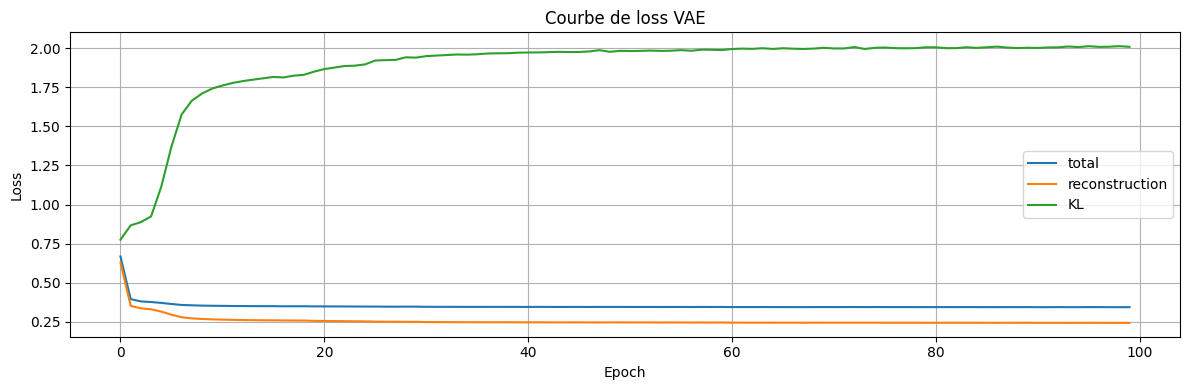

In [5]:
loader = DataLoader(VAEDataset(X_train_vae, y_train_vae), batch_size=256, shuffle=True)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

EPOCHS = 100
losses, recon_losses, kl_losses = [], [], []

for epoch in range(EPOCHS):
    vae.train()
    ep_loss = ep_recon = ep_kl = 0
    for xb, cb in loader:
        xb, cb = xb.to(DEVICE), cb.to(DEVICE)
        optimizer.zero_grad()
        recon, mu, logvar = vae(xb, cb)
        loss, recon_loss, kl_loss = vae_loss(recon, xb, mu, logvar)
        loss.backward()
        optimizer.step()
        ep_loss += loss.item()
        ep_recon += recon_loss.item()
        ep_kl += kl_loss.item()
    scheduler.step()
    losses.append(ep_loss / len(loader))
    recon_losses.append(ep_recon / len(loader))
    kl_losses.append(ep_kl / len(loader))

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch+1:3d}/{EPOCHS}  "
            f"loss={losses[-1]:.4f}  recon={recon_losses[-1]:.4f}  kl={kl_losses[-1]:.4f}"
        )

plt.plot(losses, label='total')
plt.plot(recon_losses, label='reconstruction')
plt.plot(kl_losses, label='KL')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Courbe de loss VAE'); plt.legend()
plt.tight_layout(); plt.show()


## 5.5 Génération de courbes synthétiques

In [6]:
vae.eval()
N_GEN = 50
rng = np.random.default_rng(123)

def generate(label_str, n=N_GEN):
    """Génère n courbes pour le label donné ('RS' ou 'RP')."""
    c = torch.zeros(n, 2)
    c[:, 0 if label_str == 'RS' else 1] = 1
    z = torch.randn(n, vae.latent_dim)
    with torch.no_grad():
        synth = vae.decode(z.to(DEVICE), c.to(DEVICE)).cpu().numpy()
    return scaler_vae.inverse_transform(synth)


def sample_real(label_str, n=N_GEN):
    pool = X_filt[y_filt == label_str]
    idx = rng.choice(len(pool), size=n, replace=False)
    return pool[idx]

synth_rs = generate('RS')
synth_rp = generate('RP')
real_rs = sample_real('RS')
real_rp = sample_real('RP')

print(f"Synthétiques RS : {synth_rs.shape}  |  RP : {synth_rp.shape}")
print("Échantillons réels tirés aléatoirement dans chaque classe.")


Synthétiques RS : (50, 48)  |  RP : (50, 48)
Échantillons réels tirés aléatoirement dans chaque classe.


## 5.6 Visualisation : synthétique vs réel

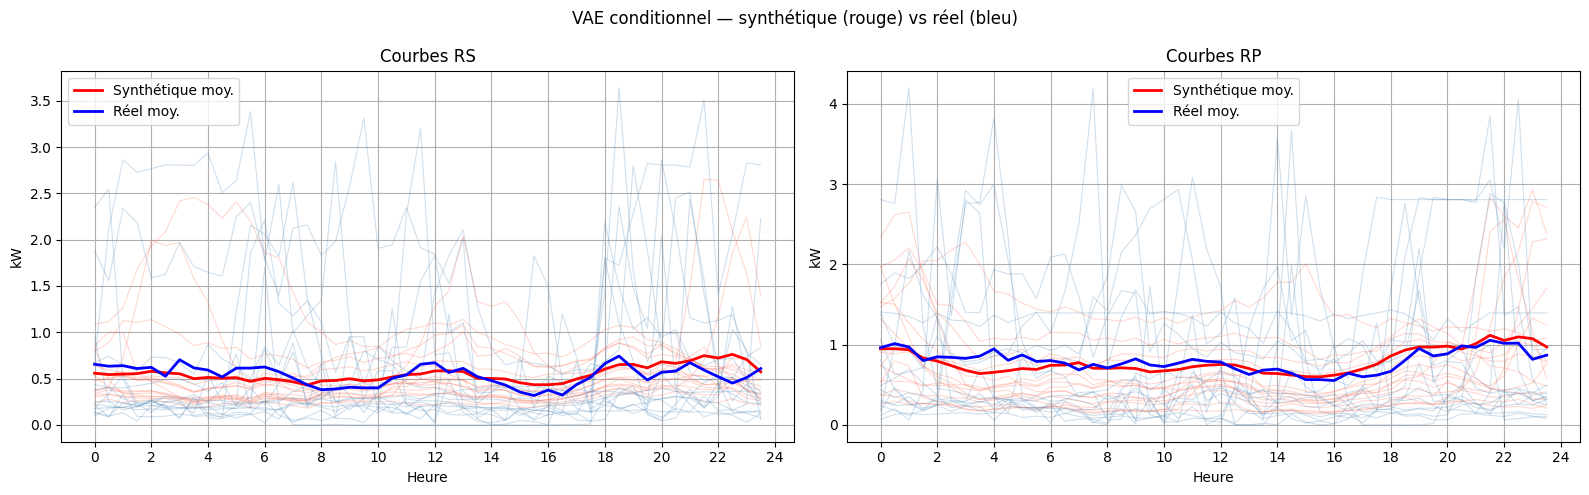

In [7]:
t = np.arange(N_SLOTS) * 0.5
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (synth, real, title) in zip(axes, [
        (synth_rs, real_rs, 'RS'),
        (synth_rp, real_rp, 'RP')]):

    for c in synth[:15]:
        ax.plot(t, c, alpha=0.25, color='tomato', linewidth=0.8)
    for c in real[:15]:
        ax.plot(t, c, alpha=0.25, color='steelblue', linewidth=0.8)

    ax.plot(t, synth.mean(axis=0), color='red',  linewidth=2, label='Synthétique moy.')
    ax.plot(t, real.mean(axis=0),  color='blue', linewidth=2, label='Réel moy.')

    ax.set_title(f'Courbes {title}')
    ax.set_xlabel('Heure'); ax.set_ylabel('kW')
    ax.set_xticks(range(0, 25, 2))
    ax.legend()

plt.suptitle('VAE conditionnel — synthétique (rouge) vs réel (bleu)', fontsize=12)
plt.tight_layout(); plt.show()

## 5.7 Métriques de similarité

In [8]:
def similarity_report(synth, real, label):
    print()
    print(f"=== {label} ===")

    e_synth = synth.sum(axis=1) * 0.5
    e_real = real.sum(axis=1) * 0.5
    print(f"Énergie moy. synthétique : {e_synth.mean():.2f} kWh")
    print(f"Énergie moy. réelle      : {e_real.mean():.2f} kWh")
    print(f"Énergie méd. synthétique : {np.median(e_synth):.2f} kWh")
    print(f"Énergie méd. réelle      : {np.median(e_real):.2f} kWh")

    stat_values, pval_values = ks_2samp(synth.flatten(), real.flatten())
    stat_energy, pval_energy = ks_2samp(e_synth, e_real)
    print(f"KS valeurs  : stat={stat_values:.4f}  p={pval_values:.4f}")
    print(f"KS énergie  : stat={stat_energy:.4f}  p={pval_energy:.4f}")

    corr = np.corrcoef(synth.mean(axis=0), real.mean(axis=0))[0, 1]
    print(f"Corrélation profil moyen : {corr:.4f}")

similarity_report(synth_rs, real_rs, 'RS')
similarity_report(synth_rp, real_rp, 'RP')



=== RS ===
Énergie moy. synthétique : 13.20 kWh
Énergie moy. réelle      : 12.86 kWh
Énergie méd. synthétique : 11.24 kWh
Énergie méd. réelle      : 11.95 kWh
KS valeurs  : stat=0.3400  p=0.0000
KS énergie  : stat=0.1200  p=0.8693
Corrélation profil moyen : 0.4633

=== RP ===
Énergie moy. synthétique : 18.90 kWh
Énergie moy. réelle      : 19.11 kWh
Énergie méd. synthétique : 16.32 kWh
Énergie méd. réelle      : 17.29 kWh
KS valeurs  : stat=0.2808  p=0.0000
KS énergie  : stat=0.1600  p=0.5487
Corrélation profil moyen : 0.7346


## 5.8 Distribution des énergies journalières

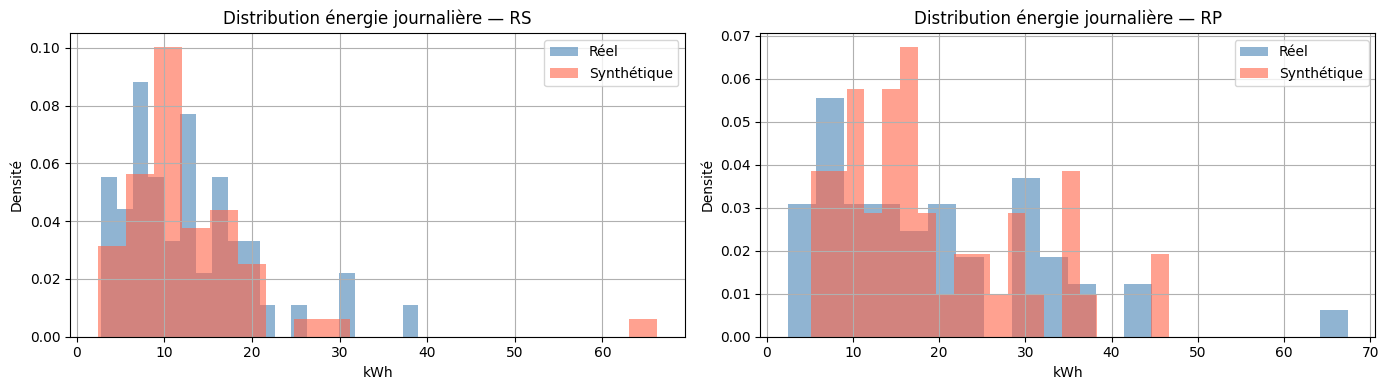

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (synth, real, title) in zip(axes, [
        (synth_rs, real_rs, 'RS'),
        (synth_rp, real_rp, 'RP')]):

    e_s = synth.sum(axis=1) * 0.5
    e_r = real.sum(axis=1)  * 0.5
    ax.hist(e_r, bins=20, alpha=0.6, color='steelblue', label='Réel', density=True)
    ax.hist(e_s, bins=20, alpha=0.6, color='tomato',    label='Synthétique', density=True)
    ax.set_title(f'Distribution énergie journalière — {title}')
    ax.set_xlabel('kWh'); ax.set_ylabel('Densité'); ax.legend()

plt.tight_layout(); plt.show()

## 5.9 Sauvegarde

In [10]:
torch.save(vae.state_dict(), '../models/vae_conditional.pt')
joblib.dump(scaler_vae, '../models/scaler_vae.pkl')

# Sauvegarde quelques courbes synthétiques pour le dashboard
np.save('../data/synth_rs.npy', synth_rs)
np.save('../data/synth_rp.npy', synth_rp)

print("Sauvegardé : vae_conditional.pt, scaler_vae.pkl, synth_rs.npy, synth_rp.npy")

Sauvegardé : vae_conditional.pt, scaler_vae.pkl, synth_rs.npy, synth_rp.npy
